# ISEL - CPS 
## Semestre 2023/24
# <br>
###  <center> Trabalho Prático 2 - Comunicações Digitais</center>
# </br>


Trabalho realizado por:
* João Ramos, numero <b> 50730 </b>
* Miguel Alcobia, numero <b> 50746 </b>
* Fábio Pestana, numero <b> 50756 </b>

<b> Turma L31 - Joel Paulo </b>

<b> Nota: na entrega o nome do ficheiro deve ser alterado para conter o número dos alunos do grupo:</b>
CPS_T2_Num1_Num2_Num3.ipynb

Devem usar o style guide PEP8: https://peps.python.org/pep-0008/


# Questão 1 – Sinal sonoro em um ponto (audição monaural) no plano horizontal, com sala

Utilizando o modelo apresentado na figura, sintetize o sinal sonoro na saída, (guarde em ficheiro WAVE),
para as seguintes situações:
1. Campo direto
2. Primeiras reflexões (ordem 1)
3. Campo Reverberante para os seguintes valores de RT60: 0s, 0.5s, 2s e 10s.
4. Campo total = Campo direto + Primeiras reflexões + Campo Reverberante <br> Nota: RT60 = 0s, indica que estamos em espaço livre (câmara anecoica), não existe
reverberação

Função de transferência do Comb Filter:
$H_{Comb}(z) = \frac{z^{-M}}{1-gz^{-M}}$

Para tirar as posições corretas das fontes sonoras e ouvinte, colocou-se um grelha sobre o esquema e recorrendo à regra de 3 simples, foram retiradas as coordenadas. Para ajudar na disposição das fontes, colocou-se uma circunferência dividida em 7 partes sob o esquema.

[Todas as imagens estarão dentro da pasta, junto do trabalho]

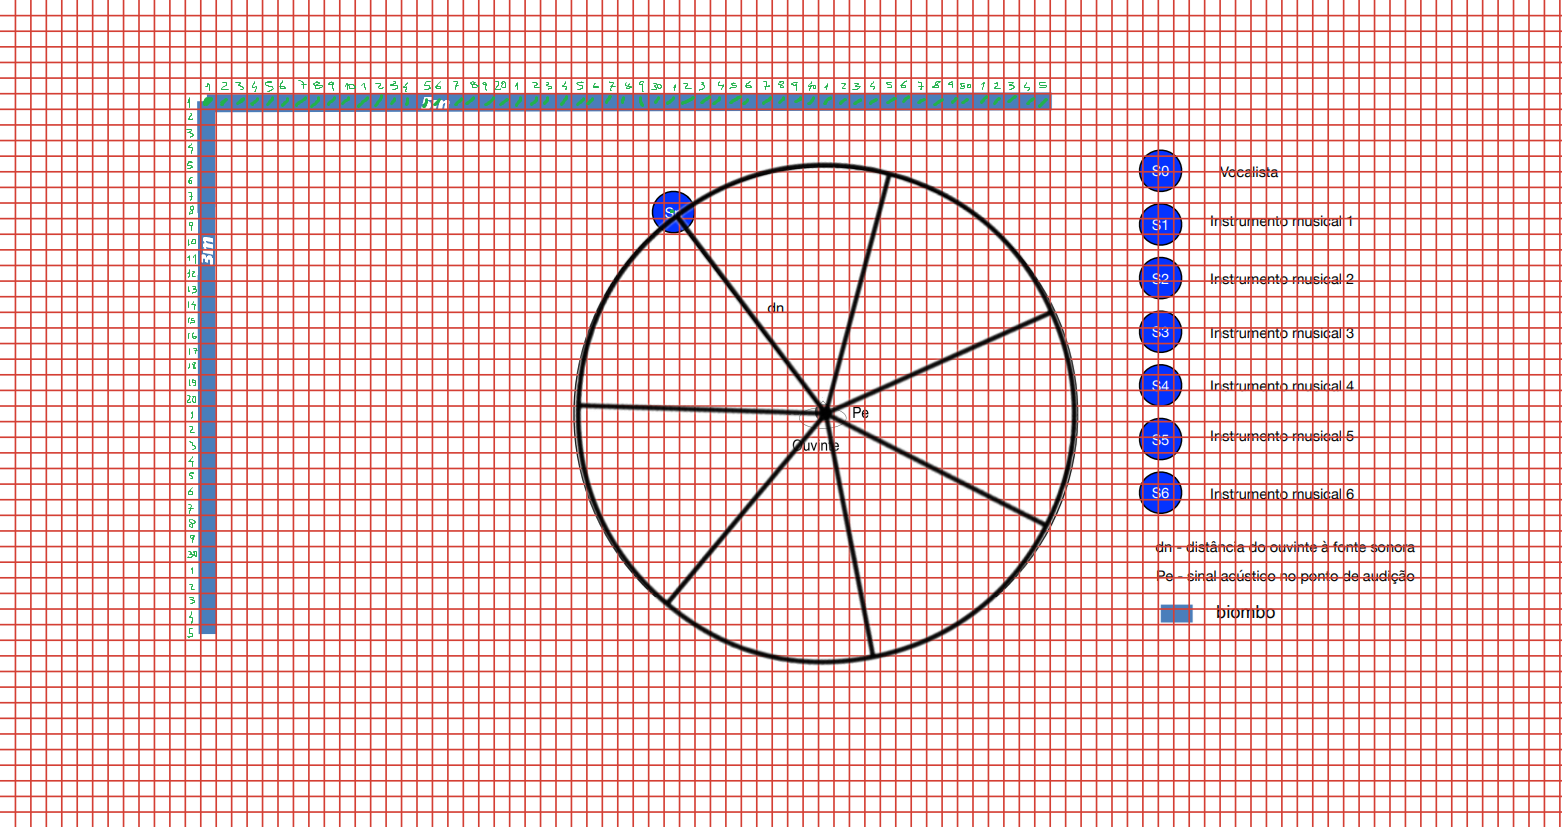

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as ss

#Plots interativos (descomentar caso seja necessário fazer zoom)
#%matplotlib widget

def calcDistanciaDelay(SalaComp, SalaLarg, OuvinteX, OuvinteY, Sx, Sy):
    """ Cálculo da distância total percorrida pelo som desde da fonte até o som, através do método das imagens

    Args:
        SalaComp: Comprimento da sala
        SalaLarg: Largura da sala
        OuvinteX: Posição em X do ouvinte
        OuvinteY: Posição em Y do ouvinte
        Sx: Posição em X da fonte sonora
        Sy: Posição em Y da fonte sonora

    Returns:
        Distância total percorrida pelo som desde da fonte até o som
    """

    distDelay = np.sqrt((SalaComp-OuvinteX+Sx)**2 + (OuvinteY-Sy))
    return distDelay

def calcTempoDelay(distanciaDelay):
    """Cálculo do tempo de delay

    Args:
        distanciaDelay: Distância percorrida pelo Som

    Returns:
        Tempo do delay desejado
    """    

    t = distanciaDelay/344
    return t

def calcG(Mi, i, RT60):
    """Cálculo do g do esquema

    Args:
        Mi: Atraso
        i: Índice do atraso
        RT60: valor de T60 desejado

    Returns:
        Valor de g desejado
    """    
    
    g = np.power(10, ((-60*Mi*48000)/RT60*20))
    g_final = np.power(g, i-1) * (1-g**2)
    return g_final

# Dimensoes da sala

# X
SalaComp = 5
# Y
SalaLarg = 3

OuvinteX = 3.73
OuvinteY = 1.80

alfa = [0, 0.5, 0.8, 1]
RT60 = [0, 0.5, 2, 10]

idx = 3

# Si's
S0x = 2.82
S0y = 0.69

S1x = 4.14
S1y = 0.47

S2x = 5
S2y = 1.24

S3x = 5
S3y = 2.44

S4x = 4
S4y = 3

S5x = 2.77
S5y = 2.83

S6x = 2.33
S6y = 1.76

# distância existente entre as fontes e o ouvinte
dn = np.sqrt((OuvinteY-S0y)**2 + (OuvinteX-S0x)**2)

# S0 calcs
distDelay0 = calcDistanciaDelay(SalaComp, SalaLarg, OuvinteX, OuvinteY, S0x, S0y)
M0_1 = calcTempoDelay(dn)
G0_1 = calcG(M0_1, 1, RT60[idx])
M0_2 = calcTempoDelay(distDelay0)
G0_2 = calcG(M0_2, 2, RT60[idx])
M0_3 = calcTempoDelay(distDelay0)
G0_3 = calcG(M0_3, 3, RT60[idx])

# S1 calcs
distDelay1 = calcDistanciaDelay(SalaComp, SalaLarg, OuvinteX, OuvinteY, S1x, S1y)
M1_1 = calcTempoDelay(dn)
G1_1 = calcG(M1_1, 1, RT60[idx])
M1_2 = calcTempoDelay(distDelay1)
G1_2 = calcG(M1_2, 2, RT60[idx])
M1_3 = calcTempoDelay(distDelay1)
G1_3 = calcG(M1_3, 3, RT60[idx])

# S2 calcs
distDelay2 = calcDistanciaDelay(SalaComp, SalaLarg, OuvinteX, OuvinteY, S2x, S2y)
M2_1 = calcTempoDelay(dn)
G2_1 = calcG(M2_1, 1, RT60[idx])
M2_2 = calcTempoDelay(distDelay2)
G2_2 = calcG(M2_2, 2, RT60[idx])
M2_3 = calcTempoDelay(distDelay2)
G2_3 = calcG(M2_3, 3, RT60[idx])

# S3 calcs
distDelay3 = calcDistanciaDelay(SalaComp, SalaLarg, OuvinteX, OuvinteY, S3x, S3y)
M3_1 = calcTempoDelay(dn)
G3_1 = calcG(M3_1, 1, RT60[idx])
M3_2 = calcTempoDelay(distDelay3)
G3_2 = calcG(M3_2, 2, RT60[idx])
M3_3 = calcTempoDelay(distDelay3)
G3_3 = calcG(M3_3, 3, RT60[idx])

# S4 calcs
distDelay4 = calcDistanciaDelay(SalaComp, SalaLarg, OuvinteX, OuvinteY, S4x, S4y)
M4_1 = calcTempoDelay(dn)
G4_1 = calcG(M4_1, 1, RT60[idx])
M4_2 = calcTempoDelay(distDelay4)
G4_2 = calcG(M4_2, 2, RT60[idx])
M4_3 = calcTempoDelay(distDelay4)
G4_3 = calcG(M4_3, 3, RT60[idx])

# S5 calcs
distDelay5 = calcDistanciaDelay(SalaComp, SalaLarg, OuvinteX, OuvinteY, S5x, S5y)
M5_1 = calcTempoDelay(dn)
G5_1 = calcG(M5_1, 1, RT60[idx])
M5_2 = calcTempoDelay(distDelay5)
G5_2 = calcG(M5_2, 2, RT60[idx])
M5_3 = calcTempoDelay(distDelay5)
G5_3 = calcG(M5_3, 3, RT60[idx])

# S6 calcs
distDelay6 = calcDistanciaDelay(SalaComp, SalaLarg, OuvinteX, OuvinteY, S6x, S6y)
M6_1 = calcTempoDelay(dn)
G6_1 = calcG(M6_1, 1, RT60[idx])
M6_2 = calcTempoDelay(distDelay5)
G6_2 = calcG(M6_2, 2, RT60[idx])
M6_3 = calcTempoDelay(distDelay5)
G6_3 = calcG(M6_3, 3, RT60[idx])


# M = 4
# g = 0.8 

def combfilter(M, g):
    # coeficientes bk, ak
    bk = np.hstack((np.zeros(M),1) )
    ak = np.hstack((1, np.zeros(np.abs(M-1)), -g))
    return bk,ak

"""
# TESTE
# Resposta em frequência
w,h = ss.freqz(bk,ak) # resposta em frequencia
plt.plot(w,np.abs(h)) # modulo da resposta em frequencia
"""

def respImpulsional(data, bk1, ak1, bk2, ak2, bk3, ak3):
    saida1 = ss.lfilter(bk1,ak1,data)
    saida2 = ss.lfilter(bk2,ak2,data)
    saida3 = ss.lfilter(bk3,ak3,data)
    paralelo = saida1+saida2+saida3
    return paralelo

"""
#TESTE
# varios comb filters 
bk1,ak1=combfilter(M=10,g=0.9)
bk2,ak2=combfilter(M=20,g=0.9)
bk3,ak3=combfilter(M=30,g=0.9)

#resposta impulsional
entrada = np.hstack((1,np.zeros(10000)))
h1 = ss.lfilter(bk1,ak1,entrada)
h2 = ss.lfilter(bk2,ak2,entrada)
h3 = ss.lfilter(bk3,ak3,entrada)
saida = h1+h2+h3

plt.figure()
plt.plot(entrada, label = "Entrada")
plt.plot(saida, label = "Saida")
plt.title('Sinais de Entrada e Saída')
plt.show()
"""

# Zona de geração dos ficheiros

import scipy.io.wavfile as wav
from IPython.display import Audio, display

path_HRTF = './HRTF/Elev0/'
path_sons = './BigStoneCulture_FragileThoughts_Full/BigStoneCulture_FragileThoughts_Full/'

filenameSom0 = '07_LeadVox.wav'
filenameSom1 = '01_Kick.wav'
filenameSom2 = '02_Snare.wav'
filenameSom3 = '03_Overhead.wav'
filenameSom4 = '04_BassDI.wav'
filenameSom5 = '05_Gtr.wav'
filenameSom6 = '06_Percussion.wav'

rate,S0data=wav.read(path_sons + filenameSom0)
rate,S1data=wav.read(path_sons + filenameSom1)
rate,S2data=wav.read(path_sons + filenameSom2)
rate,S3data=wav.read(path_sons + filenameSom3)
rate,S4data=wav.read(path_sons + filenameSom4)
rate,S5data=wav.read(path_sons + filenameSom5)
rate,S6data=wav.read(path_sons + filenameSom6)

"""
# DISPLAY DOS ORIGINAIS

display(Audio(S0data, rate = rate))
display(Audio(S1data, rate = rate))
display(Audio(S2data, rate = rate))
display(Audio(S3data, rate = rate))
display(Audio(S4data, rate = rate))
display(Audio(S5data, rate = rate))
display(Audio(S6data, rate = rate))
"""

def reverberation(data, a1, a2, b1, b2, c1, c2):
    bk1_s0, ak1_s0 = combfilter(M =  int(a1), g = int(a2))
    bk2_s0, ak2_s0 = combfilter(M = int(b1), g = int(b2))
    bk3_s0, ak3_s0 = combfilter(M = int(c1), g = int(c2))
    return respImpulsional(data, bk1_s0, ak1_s0, bk2_s0, ak2_s0, bk3_s0, ak3_s0)


paralelo0 = reverberation(S0data, M0_1, G0_1, M0_2, G0_2, M0_3, G0_3)
paralelo1 = reverberation(S1data, M1_1, G1_1, M1_2, G1_2, M1_3, G1_3)
paralelo2 = reverberation(S2data, M2_1, G2_1, M2_2, G2_2, M2_3, G2_3)
paralelo3 = reverberation(S3data, M3_1, G3_1, M3_2, G3_2, M3_3, G3_3)
paralelo4 = reverberation(S4data, M4_1, G4_1, M4_2, G4_2, M4_3, G4_3)
paralelo5 = reverberation(S5data, M5_1, G5_1, M5_2, G5_2, M5_3, G5_3)
paralelo6 = reverberation(S6data, M6_1, G6_1, M6_2, G6_2, M6_3, G6_3)

# DISPLAY DOS OUPUTS DESEJADOS

display(Audio(paralelo0, rate = rate))
display(Audio(paralelo1, rate = rate))
display(Audio(paralelo2, rate = rate))
display(Audio(paralelo3, rate = rate))
display(Audio(paralelo4, rate = rate))
display(Audio(paralelo5, rate = rate))
display(Audio(paralelo6, rate = rate))

# Questão 2 – Sinal sonoro nos ouvidos do ouvinte (audição binaural) no plano horizontal, com sala

Utilizando sinais de áudio, queremos simular o ouvinte no interior da orquestra, com os instrumentos musicais à sua volta. Apresente o sinal binaural utilizando as funções HRTF (guarde em ficheiro WAVE) para as seguintes situações:
1. Resolva a alínea anterior com coeficiente de absorção sonora, alfa, igual a 0, 0.5, 0.8 e 1. 
2. Resolva a alínea anterior com Campo Reverberante para os seguintes valores de RT60:
0s, 0.5s, 2s e 10s.

In [ ]:
def HRTF(AngSom, path_HRTF, filenameSom, xSom):
    """Função que reproduz a HRTF de um Som

    Args:
        AngSom: Angulo do Som
        path_HRTF: Path da pasta com sons referência da HRTF
        path_sons: Path da pasta com o som a que seja quer aplicar a HRTF
        filenameSom: Nome do som a que seja quer aplicar a HRTF
        xSom: Som da questao 1 com RT60 aplicado
    """    
    #Fs, xSom = wav.read(path_sons + filenameSom)
    
    xSom = xSom / np.max(np.abs(xSom))

    if(AngSom > 180):
        AngSom2 = AngSom -180
    else:
        AngSom2 = AngSom

    if(AngSom2 < 100 and AngSom2 != 0):
        HRTFname = 'H0e'+ '0' + str(AngSom2) + 'a.wav'
    elif(AngSom2 == 0 or AngSom2 == 360):
        HRTFname = 'H0e'+ '00' + str(AngSom2) + 'a.wav'
    else:
        HRTFname = 'H0e'+ str(AngSom2) + 'a.wav'

    Fs, xHRTF = wav.read(path_HRTF + HRTFname)

    xHRTF = xHRTF/(2**15)

    if(AngSom > 180):
        yL = np.convolve(xSom , xHRTF[:, 1])
        yR = np.convolve(xSom , xHRTF[:, 0])
    else:
        yL = np.convolve(xSom , xHRTF[:, 0])
        yR = np.convolve(xSom , xHRTF[:, 1])

    y = np.empty((2, len(yL)) , dtype=np.int16)

    y[0] = yL * 2**15
    y[1] = yR * 2**15

    y = np.transpose(y)

    wav.write("Resultado_HRTF_"+str(AngSom)+"_"+filenameSom, Fs, y.astype(np.int16))


# Geração de ficheiros

path_HRTF = './HRTF/Elev0/'

# Os ângulos aqui obtidos foram calculados da mesma forma que na Questão 4, 
# contudo agora no sentido horário, em vez do anti-horário.
# Como os ficheiros do HRTF são múltiplos de 5, aproximou-se os ângulos.

# AngSomX = AnguloAproximado #AnguloOrignal

AngSom0 = 325 #325
AngSom1 = 275 #274
AngSom2 = 225 #223
AngSom3 = 170 #172
AngSom4 = 120 #121
AngSom5 = 70 #70
AngSom6 = 20 #19

filenameSom0 = '07_LeadVox.wav'
filenameSom1 = '01_Kick.wav'
filenameSom2 = '02_Snare.wav'
filenameSom3 = '03_Overhead.wav'
filenameSom4 = '04_BassDI.wav'
filenameSom5 = '05_Gtr.wav'
filenameSom6 = '06_Percussion.wav'

HRTF(AngSom0, path_HRTF, filenameSom0, paralelo0)
HRTF(AngSom1, path_HRTF, filenameSom1, paralelo1)
HRTF(AngSom2, path_HRTF, filenameSom2, paralelo2)
HRTF(AngSom3, path_HRTF, filenameSom3, paralelo3)
HRTF(AngSom4, path_HRTF, filenameSom4, paralelo4)
HRTF(AngSom5, path_HRTF, filenameSom5, paralelo5)
HRTF(AngSom6, path_HRTF, filenameSom6, paralelo6)


display(Audio("Resultado_HRTF_"+str(AngSom0)+"_"+filenameSom0, rate = 44100))
display(Audio("Resultado_HRTF_"+str(AngSom1)+"_"+filenameSom1, rate = 44100))
display(Audio("Resultado_HRTF_"+str(AngSom2)+"_"+filenameSom2, rate = 44100))
display(Audio("Resultado_HRTF_"+str(AngSom3)+"_"+filenameSom3, rate = 44100))
display(Audio("Resultado_HRTF_"+str(AngSom4)+"_"+filenameSom4, rate = 44100))
display(Audio("Resultado_HRTF_"+str(AngSom5)+"_"+filenameSom5, rate = 44100))
display(Audio("Resultado_HRTF_"+str(AngSom6)+"_"+filenameSom6, rate = 44100))

# Questão 3 – Reprodução de som em sistema multicanal de altifalantes utilizando a abordagem Ambisonic, no plano horizontal, com sala.

Pretende-se codificar os sons da orquestra para serem reproduzidos em sistema de altifalantes existente
na Sala de Som Imersivo do Laboratório de Áudio e Acústica do ISEL.

Vamos codificar/descodificar as fontes sonoras no formato Ambisonic (ver slides 36 a 40). O procedimento é o seguinte:
1. Codificar as fontes sonoras nas componentes W, X, Y (slide 39), para as mesmas localizações obtidas na Questão 1 (ondas diretas e ondas refletidas);
2. Definir a geometria de localização dos altifalantes (vamos utilizar a circular com 8 altifalantes, podem não estar igualmente espaçados!);
3. Criar um microfone virtual localizado no ouvinte e que aponta na direção de cada altifalante (slide 38, com p=0.5);
4. Adiciona-se a cada canal o efeito da reverberação (filtra-se o sinal de cada canal com o filtro R(z)); Obtêm-se assim os sinais que vão ser aplicados a cada alifalante;
5. Para efeitos de comparação, obter um som binaural (slide 40), para ouvir em auscultadores, com a aplicação das HRTFs ao sinal de cada altifalante e soma dos canais L e R.

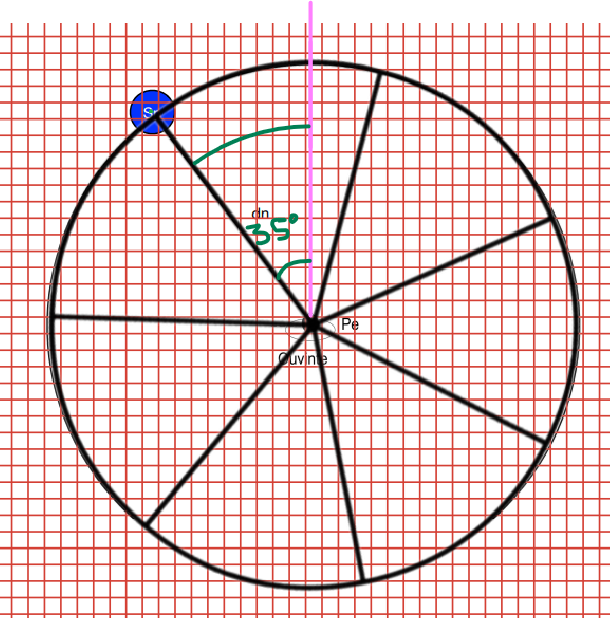

Seguiu-se a lógica apresentada no slide 38 do PowerPoint - "CPS_8.Síntese de Ambientes Sonoros Imersivos_22_23" e calculou-se os ângulos no sentido anti-horário (sentido com o qual atribuimos número às diversas fontes) e considerou-se que o ouvinte estava a olhar em frente. (O ouvinte olha na direção da linha Rosa.)

Com o auxílio da ferramenta Transferidor da Ferramenta de Recorte do Windows, concluiu-se que entre a linha rosa e Sn, representada no esquema (que será a nossa S0) estão 35 graus e entre cada fonte temos 51 graus aproximadamente.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from IPython.display import Audio, display
import scipy.signal as ss

# cada fonte tem 51 graus de diferença entre elas, sendo a s0 está a 35 graus relativamente ao ouvinte

p = 0.5 # cardioid microphone 

def cod_W(S):
    return S * 1/np.sqrt(2)

def cod_X(S, teta, fi):
    X = S * np.cos(teta) * np.cos(fi)
    return X

def cod_Y(S, teta, fi):
    Y = S * np.sin(teta) * np.cos(fi)
    return Y

def createMicro(W, X, Y, teta, p):
    M = p * np.sqrt(2)* W + (1-p) * (np.cos(teta) * X + np.sin(teta) * Y)
    return M

path_sons = './BigStoneCulture_FragileThoughts_Full/BigStoneCulture_FragileThoughts_Full/'

# S0
filenameSom0 = '07_LeadVox.wav'
Fs, S0 = wav.read(path_sons + filenameSom0)
S0 = S0 / np.max(np.abs(S0))

W0 = cod_W(S0)
X0 = cod_X(S0, 35, 0)
Y0 = cod_Y(S0, 35, 0)

microS0 = createMicro(W0, X0, Y0, 35, p)

# S1
filenameSom1 = '01_Kick.wav'
Fs, S1 = wav.read(path_sons + filenameSom1)
S1 = S1 / np.max(np.abs(S1))

W1 = cod_W(S1)
X1 = cod_X(S1, 86, 0)
Y1 = cod_Y(S1, 86, 0)

microS1 = createMicro(W1, X1, Y1, 86, p)

# S2
filenameSom2 = '02_Snare.wav'
Fs, S2 = wav.read(path_sons + filenameSom2)
S2 = S2 / np.max(np.abs(S2))

W2 = cod_W(S2)
X2 = cod_X(S2, 137, 0)
Y2 = cod_Y(S2, 137, 0)

microS2 = createMicro(W2, X2, Y2, 137, p)

# S3
filenameSom3 = '03_Overhead.wav'
Fs, S3 = wav.read(path_sons + filenameSom3)
S3 = S3 / np.max(np.abs(S3))

W3 = cod_W(S3)
X3 = cod_X(S3, 188, 0)
Y3 = cod_Y(S3, 188, 0)

microS3 = createMicro(W3, X3, Y3, 188, p)

# S4
filenameSom4 = '04_BassDI.wav'
Fs, S4 = wav.read(path_sons + filenameSom4)
S4 = S4 / np.max(np.abs(S4))

W4 = cod_W(S4)
X4 = cod_X(S4, 239, 0)
Y4 = cod_Y(S4, 239, 0)

microS4 = createMicro(W4, X4, Y4, 239, p)

# S5
filenameSom5 = '05_Gtr.wav'
Fs, S5 = wav.read(path_sons + filenameSom5)
S5 = S5 / np.max(np.abs(S5))

W5 = cod_W(S5)
X5 = cod_X(S5, 290, 0)
Y5 = cod_Y(S5, 290, 0)

microS5 = createMicro(W5, X5, Y5, 290, p)

# S6
filenameSom6 = '06_Percussion.wav'
Fs, S6 = wav.read(path_sons + filenameSom6)
S6 = S6 / np.max(np.abs(S6))

W6 = cod_W(S6)
X6 = cod_X(S6, 341, 0)
Y6 = cod_Y(S6, 341, 0)

microS6 = createMicro(W6, X6, Y6, 341, p)



Mstereo=np.vstack((microS0, microS1, microS2, microS3, microS4, microS5, microS6))


maximo=np.max(np.abs(Mstereo))
MstereoNovo = Mstereo/maximo * (2**15) -1
np.max(np.abs(MstereoNovo))
T = 32767 *2 + 1
MM = MstereoNovo.T

wav.write("teste_stereo_Questao3.wav",Fs,MM.astype('int16'))

display(Audio("teste_stereo_Questao3.wav", rate = Fs))

#plt.plot(MM)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from IPython.display import Audio, display
import scipy.signal as ss



p = 0.5 # cardioid microphone 

def codA2B_W(FLU, FRD, BLD, BRU):
    W = FLU + FRD + BLD + BRU
    return W

def codA2B_X(FLU, FRD, BLD, BRU):
    X = FLU + FRD - BLD - BRU
    return X

def codA2B_Y(FLU, FRD, BLD, BRU):
    Y = FLU - FRD + BLD - BRU
    return Y

def codA2B_Z(FLU, FRD, BLD, BRU):
    Z = FLU - FRD - BLD + BRU
    return Z

def createMicro(W, X, Y, teta, p):
    M = p * np.sqrt(2)* W + (1-p) * (np.cos(teta) * X + np.sin(teta) * Y)
    return M


# Som da Aula
filenameSom0 = 'AmbiFormatoA_Zoom.wav'
Fs, SAula = wav.read(filenameSom0)
SAula = SAula / np.max(np.abs(SAula))

# canal 1 - FLU
# canal 2 - FRD
# canal 3 - BLD
# canal 4 - BRU

FLU = SAula[:,0]
FRD = SAula[:,1]
BLD = SAula[:,2]
BRU = SAula[:,3]

WAula = codA2B_W(FLU, FRD, BLD, BRU)
XAula = codA2B_X(FLU, FRD, BLD, BRU)
YAula = codA2B_Y(FLU, FRD, BLD, BRU)
ZAula = codA2B_Z(FLU, FRD, BLD, BRU)

teta_aula = np.pi/2
microSA0 = createMicro(WAula, XAula, YAula, teta_aula, p)
microSA1 = createMicro(WAula, XAula, YAula, -teta_aula, p)



Mstereo=np.vstack((microSA0, microSA1))
maximo=np.max(np.abs(Mstereo))
MstereoNovo = Mstereo/maximo * (2**15) -1
np.max(np.abs(MstereoNovo))
T = 32767 *2 + 1
MM = MstereoNovo.T

wav.write("teste_stereo_Questao4.wav",Fs,MM.astype('int16'))

display(Audio("teste_stereo_Questao4.wav", rate = Fs))

#plt.plot(MM)